# 2.1  SNR Data
A notebook that produces the figures and tables for section 2.1

# Loading Libraries

In [1]:
# Import packages for data manipulation and visualization
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Import packages for neuron visualizations

from brainrender import Scene
from brainrender.actors import Points
import vedo
vedo.settings.default_backend= 'vtk'

# Loading data

In [2]:
# import SNR data
ec_snr_data = pd.read_csv("Data/master_detailed_comment.csv")

# Create lists of columns that relate to the counts and lengths.
# They are in the same order in the original dataframe.
length_cols = [col for col in ec_snr_data if col.endswith("_length")]
count_cols = [col for col in ec_snr_data if col.endswith("_endpoint")]


# load EC data (imputed MERFISH) object
source = "Data/ec_obj_imputed_log2.h5ad"
ec_data = ad.read_h5ad(source)

# Extract metadata that contains layer type
cell_metadata = ec_data.obs 

# Only keep the left hand side of the brain as only plotting this side
cell_metadata = cell_metadata.loc[cell_metadata['z_ccf'] > 6000].copy() 

Introducing masks for use with plotting and EDA later.

# 2.1.1 Data Introduction

## Table 1

In [3]:
ec_snr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 68 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mouseID          237 non-null    int64  
 1   neuronNR         237 non-null    int64  
 2   neuron_ID        237 non-null    object 
 3   FRP_endpoint     237 non-null    int64  
 4   FRP_length       237 non-null    float64
 5   SS_endpoint      237 non-null    int64  
 6   SS_length        237 non-null    float64
 7   VIS_endpoint     237 non-null    int64  
 8   VIS_length       237 non-null    float64
 9   VISpor_endpoint  237 non-null    int64  
 10  VISpor_length    237 non-null    float64
 11  RSP_endpoint     237 non-null    int64  
 12  RSP_length       237 non-null    float64
 13  PTLp_endpoint    237 non-null    int64  
 14  PTLp_length      237 non-null    float64
 15  ORB_endpoint     237 non-null    int64  
 16  ORB_length       237 non-null    float64
 17  MO_endpoint     

## Figure 2a

In [4]:
# Extract Seperate Projection Group Tables
orb_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "orb"]

rsp_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "rsp"]

rsp_orb_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "rsp_orb"]

nan_proj_neurons = ec_snr_data[ec_snr_data["proj"].isnull()]

# Brainrender Visuzliation
orb_points = Points(np.array(orb_proj_neurons[['x', 'y', 'z']]),
                     radius=30, colors="blue")

rsp_points = Points(np.array(rsp_proj_neurons[['x', 'y', 'z']]),
                     radius=30, colors="orange")

rsp_orb_points = Points(np.array(rsp_orb_proj_neurons[['x', 'y', 'z']]),
                     radius=30, colors="green")

nan_points = Points(np.array(nan_proj_neurons[['x', 'y', 'z']]),
                     radius=30, colors="red")

# Create a brainrender scene
scene = Scene(atlas_name="allen_mouse_25um", title="SNR Data Visualization")

# add neurons
scene.add(orb_points)
scene.add(rsp_points)
scene.add(rsp_orb_points)
scene.add(nan_points)

# add canonial MEC and LEC region meshes
lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

scene.add(lec)
scene.add(mec)

# Render
scene.render(camera="sagittal2")
scene.plotter.screenshot("Figures/fig_2a_sag.png")

## Figure 2b

In [5]:
# Extract Seperate Projection Group Tables
orb_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "orb"]

rsp_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "rsp"]

rsp_orb_proj_neurons = ec_snr_data[ec_snr_data["proj"] == "rsp_orb"]

nan_proj_neurons = ec_snr_data[ec_snr_data["proj"].isnull()]

# Brainrender Visuzliation
orb_points = Points(np.array(orb_proj_neurons[['x', 'y', 'z']]),
                     radius=30, colors="blue")

rsp_points = Points(np.array(rsp_proj_neurons[['x', 'y', 'z']]),
                     radius=30, colors="orange")

rsp_orb_points = Points(np.array(rsp_orb_proj_neurons[['x', 'y', 'z']]),
                     radius=30, colors="green")

nan_points = Points(np.array(nan_proj_neurons[['x', 'y', 'z']]),
                     radius=30, colors="red")

# Create a brainrender scene
scene = Scene(atlas_name="allen_mouse_25um", title="SNR Data Visualization")

# add neurons
scene.add(orb_points)
scene.add(rsp_points)
scene.add(rsp_orb_points)
scene.add(nan_points)

# add canonial MEC and LEC region meshes
lec = scene.add_brain_region("ENTl", alpha=0.1, color="blue")
mec = scene.add_brain_region("ENTm", alpha=0.1, color="blue")

scene.add(lec)
scene.add(mec)

# Render
scene.render(camera="top")
scene.plotter.screenshot("Figures/fig_2b_top.png")

# 2.1.2 EDA

## Columns, Missingness and value counts

First explore the columns, value counts in some columns of interest and check for missing data

In [6]:
# List the columns in SNR data
print('The columns in the SNR data are:')
print(ec_snr_data.columns)

print('\nValue counts of the comment column:')
print(ec_snr_data['comment'].value_counts(dropna=False))

print('\nValue counts of the count column (not included in final data):')
print(ec_snr_data['count'].value_counts(dropna=False))

print('\nValue counts of the injection column:')
print(ec_snr_data['injection'].value_counts(dropna=False))

print('\nChecking for missing data:')
ec_snr_data.info()

The columns in the SNR data are:
Index(['mouseID', 'neuronNR', 'neuron_ID', 'FRP_endpoint', 'FRP_length',
       'SS_endpoint', 'SS_length', 'VIS_endpoint', 'VIS_length',
       'VISpor_endpoint', 'VISpor_length', 'RSP_endpoint', 'RSP_length',
       'PTLp_endpoint', 'PTLp_length', 'ORB_endpoint', 'ORB_length',
       'MO_endpoint', 'MO_length', 'AUD_endpoint', 'AUD_length',
       'ACA_endpoint', 'ACA_length', 'PL_endpoint', 'PL_length',
       'ILA_endpoint', 'ILA_length', 'VISC_endpoint', 'VISC_length',
       'AI_endpoint', 'AI_length', 'GU_endpoint', 'GU_length', 'TEa_endpoint',
       'TEa_length', 'PERI_endpoint', 'PERI_length', 'ECT_endpoint',
       'ECT_length', 'OLF_endpoint', 'OLF_length', 'PAR_endpoint',
       'PAR_length', 'POST_endpoint', 'POST_length', 'PRE_endpoint',
       'PRE_length', 'SUB_endpoint', 'SUB_length', 'HIP_endpoint',
       'HIP_length', 'CLA_endpoint', 'CLA_length', 'EP_endpoint', 'EP_length',
       'AMY_endpoint', 'AMY_length', 'STRd_endpoint', 'STR

##

## Fig 3 - spearman's rank between lengths and endpoints, along with distribution of zeros across regions.

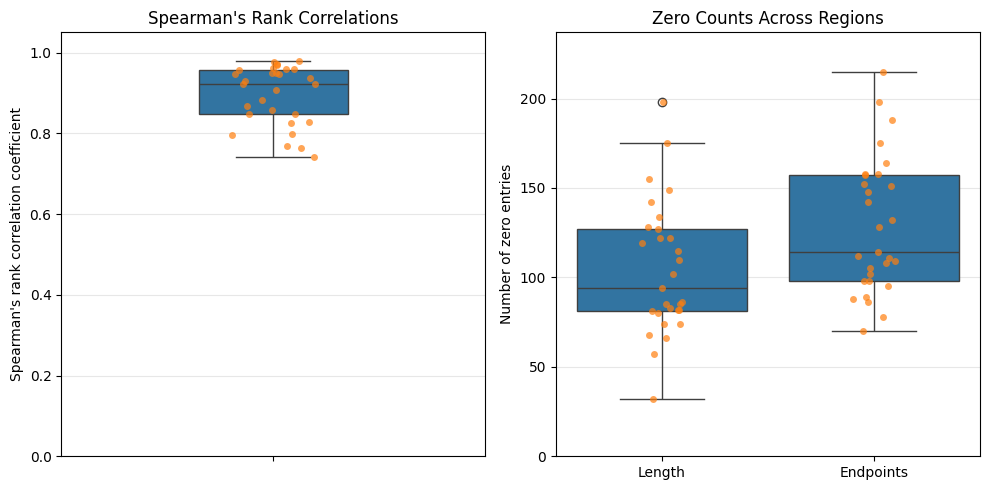

In [7]:
# Object to save results in
corr_results = []

# Calculate spearman's rank and number of zeros in each region, saving all the results in a dictionary to turn into a dataframe
for length_col, count_col in zip(length_cols, count_cols):
    region = length_col.removesuffix("_length")
    
    spearman_r, spearman_p = spearmanr(ec_snr_data[length_col], ec_snr_data[count_col])

    corr_results.append({
        "region": region,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
        "length_zeros": (ec_snr_data[length_col] == 0).sum(),
        "endpoint_zeros": (ec_snr_data[count_col] == 0).sum(),
        "n": len(ec_snr_data),
    })

# create dataframe from the above dictionary
corr_df = pd.DataFrame(corr_results)

# Convert zero counts to long format for seaborn
zero_df = corr_df.melt(
    id_vars="region",
    value_vars=["length_zeros", "endpoint_zeros"],
    var_name="variable",
    value_name="zero_count"
)

zero_df["variable"] = zero_df["variable"].map({
    "length_zeros": "Length",
    "endpoint_zeros": "Endpoints"
})




#  Create the boxplot object
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Boxplot of Spearman correlations
sns.boxplot(
    data=corr_df,
    y="spearman_r",
    ax=axes[0],
    width = 0.35
)

sns.stripplot(
    data=corr_df,
    y="spearman_r",
    ax=axes[0],
    alpha=0.7,
    jitter=True
)

axes[0].set_title("Spearman's Rank Correlations")
axes[0].set_ylabel("Spearman's rank correlation coefficient")
axes[0].set_xlabel("")
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", alpha=0.3)

# Boxplot of zero counts
sns.boxplot(
    data=zero_df,
    x="variable",
    y="zero_count",
    ax=axes[1]
)

sns.stripplot(
    data=zero_df,
    x="variable",
    y="zero_count",
    ax=axes[1],
    alpha=0.7,
    jitter=True
)

axes[1].set_title("Zero Counts Across Regions")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of zero entries")
axes[1].set_ylim(0, len(ec_snr_data))
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Figures/Fig_3_boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
# Check that all regions exhibit strong correlation (>0.7)
corr_df['spearman_r']>0.7


0     True
1     True
2     True
3     True
4     True
5     True
6     True
7     True
8     True
9     True
10    True
11    True
12    True
13    True
14    True
15    True
16    True
17    True
18    True
19    True
20    True
21    True
22    True
23    True
24    True
25    True
26    True
27    True
28    True
Name: spearman_r, dtype: bool

## Log transformations

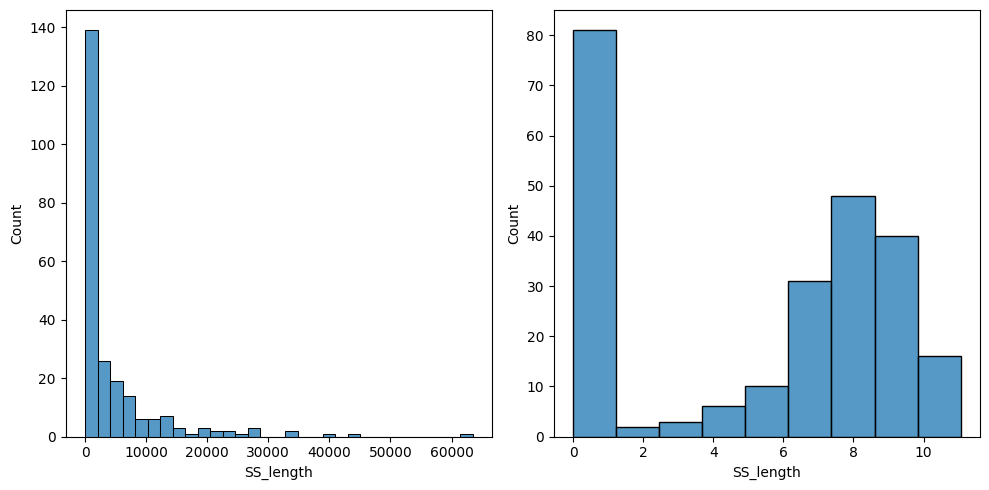

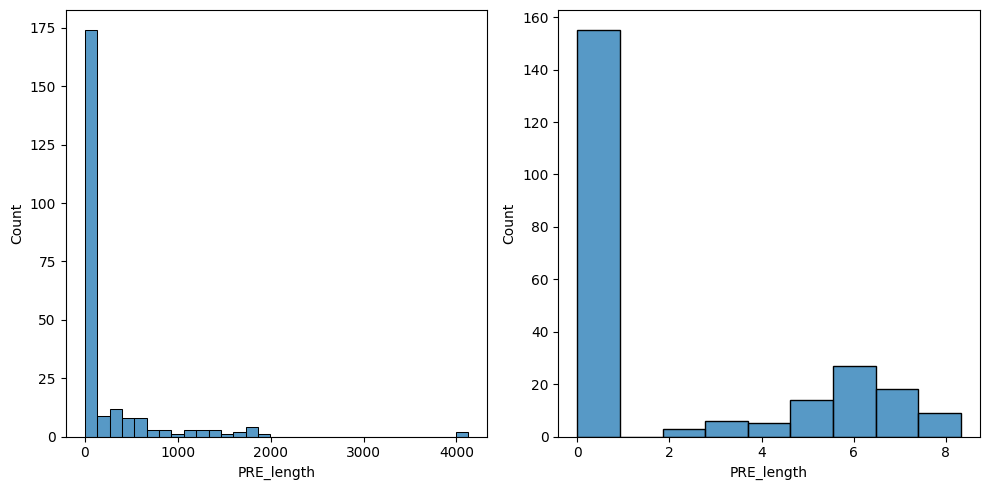

In [9]:
# Visualize the distribution of end points and lengths colored by projection type
ec_snr_log = ec_snr_data.copy()

# Take logs of all the values
ec_snr_log[length_cols] = np.log1p(ec_snr_log[length_cols])
ec_snr_log[count_cols] = np.log1p(ec_snr_log[count_cols])



# Plot original and transformed values for comparison in 2 different regions.
# Region 1:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(data=ec_snr_data, x='SS_length', multiple='dodge', ax=axes[0])
sns.histplot(data=ec_snr_log, x='SS_length', multiple='dodge', ax=axes[1])
plt.tight_layout()
plt.show()


# Region 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(data=ec_snr_data, x='PRE_length', multiple='dodge', ax=axes[0])
sns.histplot(data=ec_snr_log, x='PRE_length', multiple='dodge', ax=axes[1])
plt.tight_layout()
plt.show()